In [2]:
!pip install matplotlib seaborn scikit-learn pandas numpy joblib streamlit


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
#Building a cardiovascular disease prediction model using dataset from Kaggle.  The data has been cleaned by my other teammate. I have the role of building the model to predict and then pass the code for streamlit app deployment. State the steps to be followed for model building and provide code for the same as well. Here is the code that was used for data cleaning:

import pandas as pd

# Load dataset
df = pd.read_csv('cardio_train.csv', sep=';')





In [4]:
# Remove ID column
df = df.drop(columns=['id'])

In [5]:
# Convert age from days to years
df['age'] = (df['age'] / 365.25).round(1)

In [6]:
# Remove invalid blood pressure values
df = df[(df['ap_hi'] >= 60) & (df['ap_hi'] <= 250) & (df['ap_lo'] >= 40) & (df['ap_lo'] <= 150) &(df['ap_hi'] > df['ap_lo'])]

In [7]:

# Remove unrealistic height and weight values
df = df[(df['height'] >= 100) & (df['height'] <= 220) & (df['weight'] >= 20) & (df['weight'] <= 250)]


In [8]:

# Create BMI feature
df['bmi'] = (df['weight'] / ((df['height'] / 100) ** 2)).round(1)


In [9]:

# Remove unrealistic BMI values
df = df[df['bmi'].between(10, 60)]


In [10]:

# Dataset summary
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df['cardio'].value_counts())
print("\nSample Data:\n", df.head())


Shape: (68601, 13)

Missing Values:
 age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
bmi            0
dtype: int64

Target Distribution:
 cardio
0    34664
1    33937
Name: count, dtype: int64

Sample Data:
     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  \
0  50.4       2     168    62.0    110     80            1     1      0     0   
1  55.4       1     156    85.0    140     90            3     1      0     0   
2  51.6       1     165    64.0    130     70            3     1      0     0   
3  48.2       2     169    82.0    150    100            1     1      0     0   
4  47.8       1     156    56.0    100     60            1     1      0     0   

   active  cardio   bmi  
0       1       0  22.0  
1       1       1  34.9  
2       0       1  23.5  
3       1       1  28.7  
4       0       0  

In [11]:

# Save cleaned dataset
df.to_csv('cardio_cleaned.csv', index=False)


In [12]:
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [13]:

data_path = 'cardio_cleaned.csv'



In [14]:
# Create a new feature: Pulse Pressure
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

In [15]:

# Guard Clause
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Error: '{data_path}' not found! Make sure it is in the same folder.")


In [16]:

# 1. Load data & Split
print("Loading data...")
df = pd.read_csv(data_path)
X = df.drop(columns=['cardio'])
y = df['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Loading data...


In [17]:

# 2. Simple, Explainable Tuning (Grid Search)
print("Finding the best model parameters...")
# We only test a few options so it runs fast and is easy to explain
param_grid = {
    'n_estimators': [100, 200, 300],         # Test more trees
    'max_depth': [10, 15, 20],               # Test deeper trees
    'min_samples_split': [2, 5, 10]          # Prevent trees from making decisions on too few patients
}

base_model = RandomForestClassifier(random_state=42)
# cv=3 means it cross-validates the data 3 times to ensure stability
grid_search = GridSearchCV(base_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)


Finding the best model parameters...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defaul

In [18]:

# Extract the winning model
best_model = grid_search.best_estimator_

# 3. Evaluate the tuned model
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n--- Final Results ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Optimized Model Accuracy: {accuracy * 100:.2f}%")



--- Final Results ---
Best Parameters Found: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Optimized Model Accuracy: 73.78%


In [19]:

# 4. Save the model for Member 3 (Streamlit)
model_filename = 'cardio_rf_model.pkl'
joblib.dump(best_model, model_filename)


['cardio_rf_model.pkl']


Generating Feature Importance Chart...


/tmp/ipykernel_36493/603418291.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


Chart saved as 'feature_importance.png'. Give this to Member 4 for the PPT!


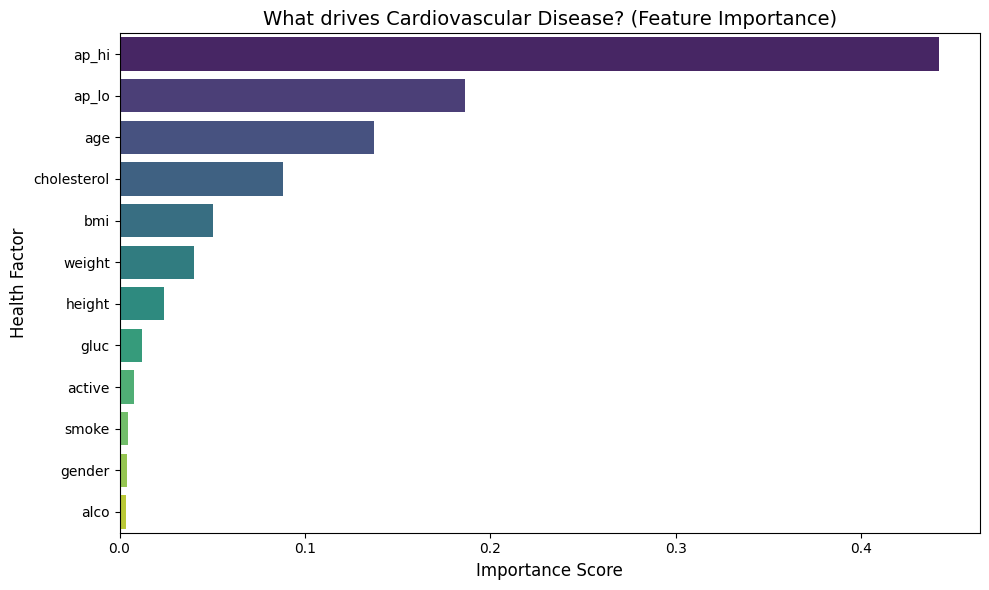

In [20]:

# 5. Generate Feature Importance Chart for Member 4 (PPT)
print("\nGenerating Feature Importance Chart...")
feature_importances = best_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plotting the chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('What drives Cardiovascular Disease? (Feature Importance)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Health Factor', fontsize=12)
plt.tight_layout()

# Save the chart as an image
image_filename = 'feature_importance.png'
plt.savefig(image_filename)
print(f"Chart saved as '{image_filename}'. Give this to Member 4 for the PPT!")



In [21]:
# 6. Environment Check for Auto-Download (Colab vs GitHub)
try:
    from google.colab import files
    print("\nGoogle Colab detected. Downloading model and chart...")
    files.download(model_filename)
    files.download(image_filename)
except ImportError:
    print(f"\nRunning locally. '{model_filename}' and '{image_filename}' are saved in your folder.")


Running locally. 'cardio_rf_model.pkl' and 'feature_importance.png' are saved in your folder.


In [25]:
import pickle

# Save your actual optimized model to a file using pickle
with open('cardio_rf_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)